In [1]:
from s3_dataset_index import parse_s3_dataset

BASE_PATH = "s3://aind-benchmark-data/mesoscale-anatomy-cell-detection/train/"
training_sets = [
    "training_set_02032024",
    "training_set_2025_02_01",
    "training_set_2025_10_20",
    "training_set_2026_01_09",
]
training_sets_points = {}

for ts in training_sets:
    dataset_path = f"{BASE_PATH}{ts}/"
    dataset_index = parse_s3_dataset(
        dataset_path
    )
    training_sets_points[ts] = {
        "base_path": dataset_path,
        "dataset_index": dataset_index
    }
    print(f"Dataset index for {ts}: Datasets {len(dataset_index.keys())}")


Dataset index for training_set_02032024: Datasets 16
Dataset index for training_set_2025_02_01: Datasets 5
Dataset index for training_set_2025_10_20: Datasets 3
Dataset index for training_set_2026_01_09: Datasets 3


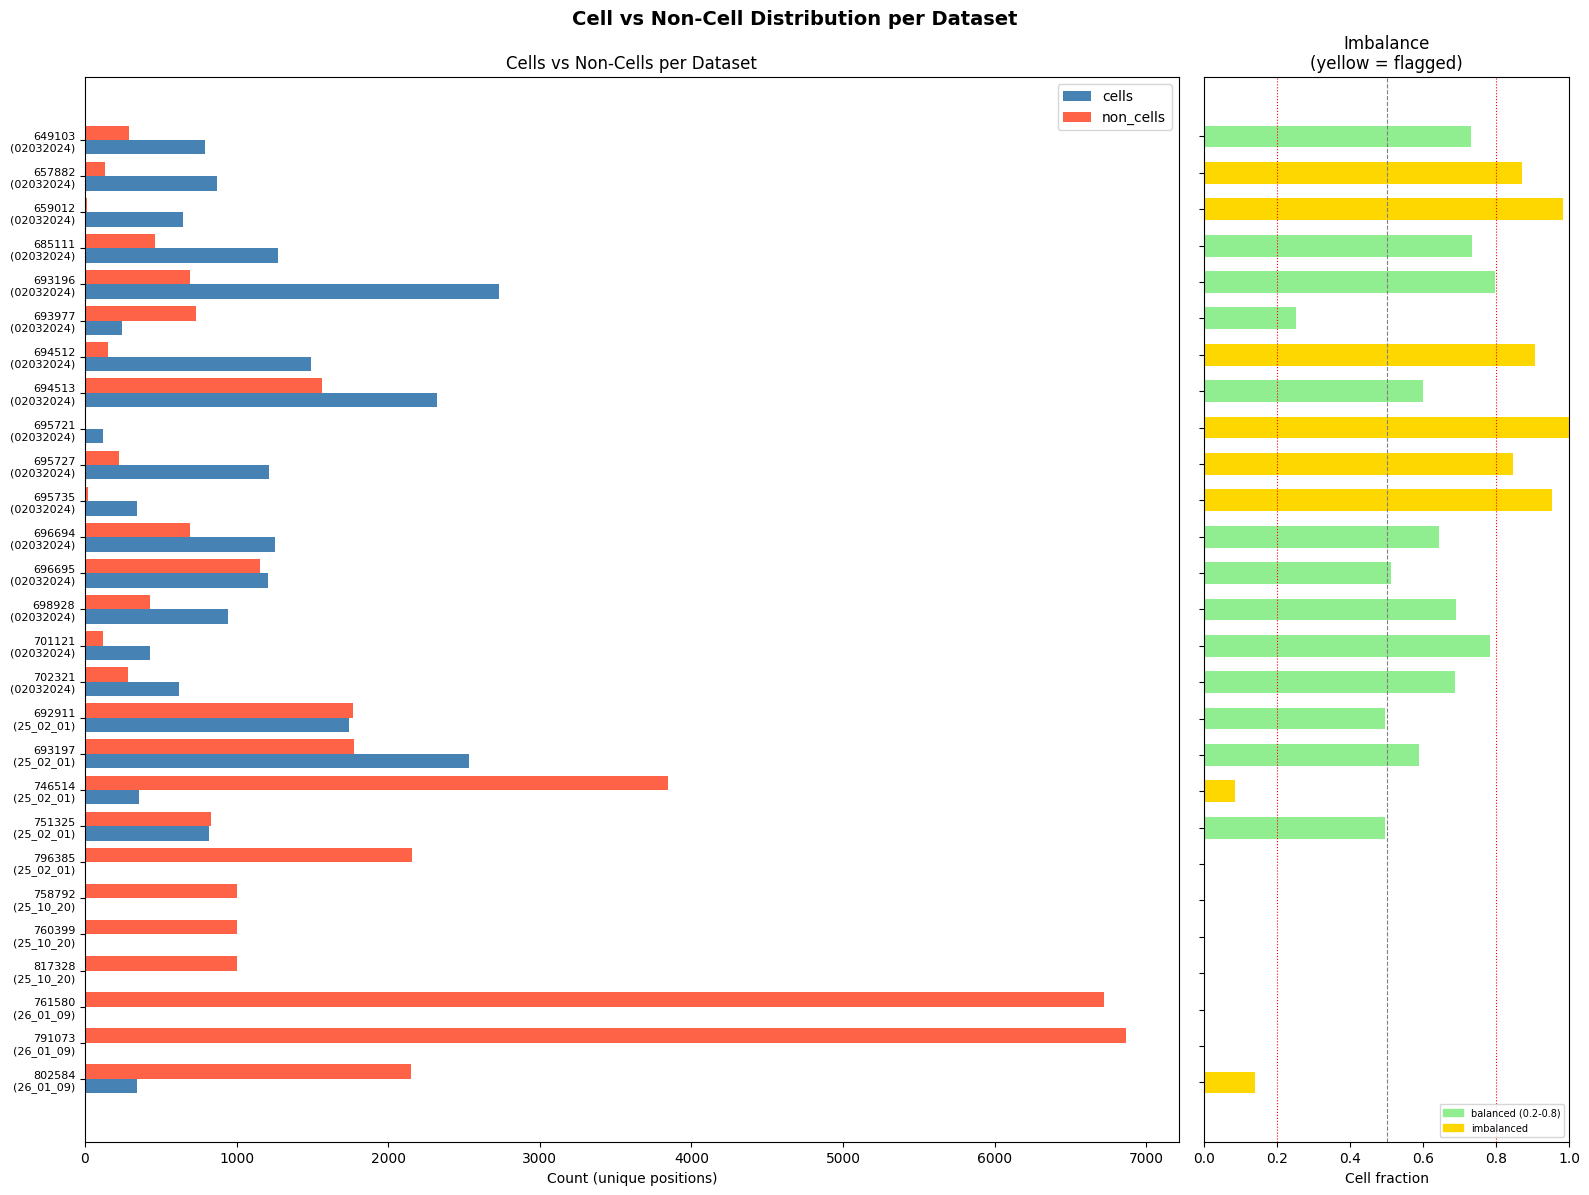

Flagged datasets: 14 / 27
           training_set dataset_id  n_cells  n_non_cells  cell_ratio
  training_set_02032024     657882      868          130    0.869739
  training_set_02032024     659012      649           11    0.983333
  training_set_02032024     694512     1493          153    0.907047
  training_set_02032024     695721      116            0    1.000000
  training_set_02032024     695727     1214          222    0.845404
  training_set_02032024     695735      343           17    0.952778
training_set_2025_02_01     746514      356         3843    0.084782
training_set_2025_02_01     796385        0         2160    0.000000
training_set_2025_10_20     758792        0         1000    0.000000
training_set_2025_10_20     760399        0         1000    0.000000
training_set_2025_10_20     817328        0         1000    0.000000
training_set_2026_01_09     761580        0         6724    0.000000
training_set_2026_01_09     791073        0         6869    0.000000
training

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Aggregate unique positions per dataset ID across all channel folders
rows = []
for ts, ts_data in training_sets_points.items():
    for dataset_id, channels in ts_data["dataset_index"].items():
        all_cells = set()
        all_non_cells = set()
        for ch_data in channels.values():
            all_cells.update(ch_data["cells"])
            all_non_cells.update(ch_data["non_cells"])
        rows.append({
            "training_set": ts,
            "dataset_id": dataset_id,
            "n_cells": len(all_cells),
            "n_non_cells": len(all_non_cells),
        })

df = pd.DataFrame(rows).sort_values(["training_set", "dataset_id"]).reset_index(drop=True)
df["total"] = df["n_cells"] + df["n_non_cells"]
df["cell_ratio"] = df["n_cells"] / df["total"].replace(0, np.nan)
df["label"] = df["dataset_id"] + "\n(" + df["training_set"].str[-8:] + ")"

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df) * 0.45)),
                         gridspec_kw={"width_ratios": [3, 1]})
fig.suptitle("Cell vs Non-Cell Distribution per Dataset", fontsize=14, fontweight="bold")

y = np.arange(len(df))
bar_h = 0.4

ax = axes[0]
bars_c  = ax.barh(y + bar_h / 2, df["n_cells"],     height=bar_h, color="steelblue", label="cells")
bars_nc = ax.barh(y - bar_h / 2, df["n_non_cells"], height=bar_h, color="tomato",    label="non_cells")
ax.set_yticks(y)
ax.set_yticklabels(df["label"], fontsize=8)
ax.set_xlabel("Count (unique positions)")
ax.set_title("Cells vs Non-Cells per Dataset")
ax.legend(handles=[bars_c, bars_nc])
ax.invert_yaxis()

ax2 = axes[1]
flag_colors = ["gold" if (r < 0.2 or r > 0.8) else "lightgreen"
               for r in df["cell_ratio"].fillna(0)]
ax2.barh(y, df["cell_ratio"], height=0.6, color=flag_colors)
ax2.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax2.axvline(0.2, color="red",  linestyle=":",  linewidth=0.8)
ax2.axvline(0.8, color="red",  linestyle=":",  linewidth=0.8)
ax2.set_xlim(0, 1)
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Cell fraction")
ax2.set_title("Imbalance\n(yellow = flagged)")
ax2.invert_yaxis()
ax2.legend(handles=[
    mpatches.Patch(color="lightgreen", label="balanced (0.2-0.8)"),
    mpatches.Patch(color="gold",       label="imbalanced"),
], fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

# Summary
# 0.2 and 0.8 picked as a 4:1 ratio between cells and non cells
flagged = df[(df["cell_ratio"] < 0.2) | (df["cell_ratio"] > 0.8)]
print(f"Flagged datasets: {len(flagged)} / {len(df)}")
if not flagged.empty:
    print(flagged[["training_set", "dataset_id", "n_cells", "n_non_cells", "cell_ratio"]]
          .to_string(index=False))
    
# total cells vs non cells across all datasets
total_cells = df["n_cells"].sum()
total_non_cells = df["n_non_cells"].sum()
total_ratio = total_cells / (total_cells + total_non_cells)
print(f"\nOverall cell ratio across all datasets: {total_ratio:.2%} "
      f"({total_cells} cells vs {total_non_cells} non-cells)")


In [3]:
# Sampling weights for WeightedRandomSampler
# weight_map[ts][dataset_id] = {"cell": w, "non_cell": w}
# Inverse-frequency weights, normalised so the mean weight per dataset = 1.
weight_map = {}
for ts, ts_data in training_sets_points.items():
    weight_map[ts] = {}
    for dataset_id, channels in ts_data["dataset_index"].items():
        all_cells:     set = set()
        all_non_cells: set = set()
        for ch_data in channels.values():
            all_cells.update(ch_data["cells"])
            all_non_cells.update(ch_data["non_cells"])
        n_c, n_nc = len(all_cells), len(all_non_cells)
        total = n_c + n_nc
        if total == 0:
            continue
        weight_map[ts][dataset_id] = {
            "cell":     total / (2 * n_c)  if n_c  > 0 else 0.0,
            "non_cell": total / (2 * n_nc) if n_nc > 0 else 0.0,
        }

rows_w = [
    {"training_set": ts, "dataset_id": did, **w}
    for ts, ds_map in weight_map.items()
    for did, w in ds_map.items()
]
print(pd.DataFrame(rows_w).to_string(index=False))


           training_set dataset_id     cell  non_cell
  training_set_02032024     649103 0.684576  1.854452
  training_set_02032024     657882 0.574885  3.838462
  training_set_02032024     659012 0.508475 30.000000
  training_set_02032024     685111 0.680926  1.881779
  training_set_02032024     693196 0.627243  2.464748
  training_set_02032024     693977 1.991837  0.667579
  training_set_02032024     694512 0.551239  5.379085
  training_set_02032024     694513 0.835773  1.244551
  training_set_02032024     695721 0.500000  0.000000
  training_set_02032024     695727 0.591433  3.234234
  training_set_02032024     695735 0.524781 10.588235
  training_set_02032024     696694 0.775738  1.406657
  training_set_02032024     696695 0.978856  1.022078
  training_set_02032024     698928 0.725397  1.609155
  training_set_02032024     701121 0.638889  2.300000
  training_set_02032024     702321 0.728663  1.593310
training_set_2025_02_01     692911 1.007759  0.992360
training_set_2025_02_01     

In [4]:
import dask.array as da
import numpy as np
import torch
from aind_lightsheet_mae.model.lightning_modules import Lightsheet3DMAE
from mesoscale_cell_classification_head.pipeline import _default_config, _iter_cell_features
from mesoscale_cell_classification_head.spatial import greedy_cover_gpu
from mesoscale_cell_classification_head.preprocessing import zscore_val_augmentations

bucket_name = "aind-open-data"
prefix = "image_tile_fusing/OMEZarr/"
dataset_zarr_paths: dict[str, str] = {
    "695727": {
        "base_path": "SmartSPIM_695727_2023-09-27_18-02-20_stitched_2023-10-28_20-40-06",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_600.zarr"],
        "background": "Ex_639_Em_680.zarr"            
    },
}
checkpoint_path = "./mae_S_rope_best_model.ckpt"

cfg = _default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_transform = zscore_val_augmentations()

reconstruction_model = (
    Lightsheet3DMAE.load_from_checkpoint(
        checkpoint_path,
        weights_only=False,
        strict=False,
        loss_fn=None,
    )
    .half().to(device).eval()
)

/home/camilo/.conda/envs/cell_classification/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: object of type 'int' has no len()

In [ ]:
all_features: list[np.ndarray] = []
all_labels:   list[np.ndarray] = []
viz_samples:  list              = []   # (raw_crop, feat_vec, label_str, pos)

for ts, ts_data in training_sets_points.items():
    for dataset_id, channels in ts_data["dataset_index"].items():
        if dataset_id not in dataset_zarr_paths:
            continue

        cells_set:     set = set()
        non_cells_set: set = set()
        for ch_data in channels.values():
            cells_set.update(ch_data["cells"])
            non_cells_set.update(ch_data["non_cells"])

        all_positions = list(non_cells_set) + list(cells_set)
        if not all_positions:
            continue

        cell_zyx    = np.array(all_positions, dtype=np.int64)
        cell_zyx_ds = cell_zyx // (2 ** cfg["scale"])

        label_lookup_ds: dict[tuple, int] = {}
        for pos in non_cells_set:
            label_lookup_ds[tuple(np.array(pos, dtype=np.int64) // (2 ** cfg["scale"]))] = 0
        for pos in cells_set:
            label_lookup_ds[tuple(np.array(pos, dtype=np.int64) // (2 ** cfg["scale"]))] = 1

        loaded_zarr = da.squeeze(da.from_zarr(f"{dataset_zarr_paths[dataset_id]}/{cfg['scale']}"))

        boxes, box_cells_ids = greedy_cover_gpu(
            cell_zyx_ds, loaded_zarr.shape,
            box_size=cfg["box_size"], vox=cfg["vox"], verbose=False,
        )
        if not boxes:
            continue

        for feats, global_points in _iter_cell_features(
            boxes, box_cells_ids, cell_zyx_ds, loaded_zarr,
            reconstruction_model, device, cfg,
            desc=f"{ts}/{dataset_id}",
            val_transform=val_transform,
        ):
            labels = np.array(
                [label_lookup_ds.get(tuple(pt), -1) for pt in global_points],
                dtype=np.int8,
            )
            valid    = labels >= 0
            feats_np = feats.cpu().numpy()

            # Collect up to 5 (crop, feat_vec) samples for visualization
            if len(viz_samples) < 5:
                box_half = cfg["box_dim"] // 2
                for pt, fv, lbl in zip(global_points[valid], feats_np[valid], labels[valid]):
                    if len(viz_samples) >= 5:
                        break
                    z0 = max(0, int(pt[0]) - box_half)
                    y0 = max(0, int(pt[1]) - box_half)
                    x0 = max(0, int(pt[2]) - box_half)
                    crop = np.asarray(
                        loaded_zarr[
                            z0:z0 + cfg["box_dim"],
                            y0:y0 + cfg["box_dim"],
                            x0:x0 + cfg["box_dim"],
                        ].compute(),
                        dtype=np.float32,
                    )
                    viz_samples.append((crop, fv, "cell" if lbl == 1 else "non_cell", tuple(pt)))

            all_features.append(feats_np[valid])
            all_labels.append(labels[valid])

X = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels,   axis=0)
print(f"X: {X.shape}  y: {y.shape}")
print(f"cells: {(y == 1).sum()}  non_cells: {(y == 0).sum()}")
print(f"Storage (float32): {X.nbytes / 1e6:.1f} MB")
np.savez_compressed("classifier_features.npz", X=X, y=y)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = len(viz_samples)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle("Raw Z-MIP  vs  Feature Vector", fontsize=13, fontweight="bold")

for col, (crop, fv, label, pos) in enumerate(viz_samples):
    # Row 0: raw max-intensity projection along Z
    axes[0, col].imshow(crop.max(axis=0), cmap="gray")
    axes[0, col].set_title(f"{label}\nz={pos[0]} y={pos[1]} x={pos[2]}", fontsize=7)
    axes[0, col].axis("off")

    # Row 1: feature vector as a 2-D heatmap (reshape to nearest square)
    C = len(fv)
    side = int(np.ceil(np.sqrt(C)))
    padded = np.zeros(side * side)
    padded[:C] = fv
    axes[1, col].imshow(padded.reshape(side, side), cmap="viridis", aspect="auto")
    axes[1, col].set_title(f"‖f‖={np.linalg.norm(fv):.2f}", fontsize=7)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Raw Z-MIP",      fontsize=9, labelpad=6)
axes[1, 0].set_ylabel("Feature vector", fontsize=9, labelpad=6)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

data  = np.load("classifier_features.npz")
X_all = data["X"].astype(np.float32)
y_all = data["y"].astype(np.int64)
print(f"Loaded: X={X_all.shape}  cells={(y_all==1).sum()}  non_cells={(y_all==0).sum()}")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# Inverse-frequency weights for balanced mini-batches
n_c, n_nc = (y_tr == 1).sum(), (y_tr == 0).sum()
w = np.where(y_tr == 1, len(y_tr) / (2 * n_c), len(y_tr) / (2 * n_nc)).astype(np.float32)
sampler = WeightedRandomSampler(torch.from_numpy(w), num_samples=len(y_tr), replacement=True)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=256, sampler=sampler,
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=512, shuffle=False,
)

# MLP head: input_dim → 256 → 64 → 2
in_dim = X_all.shape[1]
head = nn.Sequential(
    nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256,     64), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64,       2),
).to(device)

optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.CrossEntropyLoss()

n_epochs = 50
train_losses, val_losses, val_accs = [], [], []

for epoch in range(n_epochs):
    head.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(head(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(yb)
    train_losses.append(running / len(y_tr))
    scheduler.step()

    head.eval()
    vloss, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = head(xb)
            vloss   += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
    val_losses.append(vloss / len(y_val))
    val_accs.append(correct / len(y_val))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}  train={train_losses[-1]:.4f}"
              f"  val={val_losses[-1]:.4f}  acc={val_accs[-1]:.3f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses,   label="val")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[0].legend()
axes[1].plot(val_accs)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].set(title="Val accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
plt.tight_layout()
plt.show()

torch.save(head.state_dict(), "classifier_head.pt")
print(f"\nFinal val accuracy: {val_accs[-1]:.3f}")